# Network Analysis — Assignment 02
## Tails on Westeros: null models and the degree exponent

**Course:** Network Analysis 2025/26  
**Group size:** 4 students  

**Group:**

Member 1: Beatriz Soares Marques -- 20231605 \
Member 2: Maria Inês Lopes dos Santos -- 20231630 \
Member 3: Luís Rafael da Costa Soeiro -- 20211536 \
Member 4: Rodrigo Teixeira da Silva -- 20231602

---

### Big picture

Assignment 01 asked you to **describe** the co-occurrence network. Here the goal is different: you connect **generative stories** (who gets edges, and why?) to **what we see in degree data**, and you learn to **put a number** on a heavy tail: first **where** the “tail” begins (degrees above a cutoff), then **how steep** that tail is (the **tail exponent** from the course). You also see how far **random wiring** with the **right degrees** can mimic the real story — and where it cannot.

---

### Dataset

**Network of Thrones — Book 1** (Beveridge and Shan).  
https://raw.githubusercontent.com/mathbeveridge/asoiaf/master/data/asoiaf-book1-edges.csv  

Build an **undirected simple** graph from **`Source`** and **`Target`** (ignore weights: an edge = at least one co-occurrence).

---

### Notation (plain)

- **Tail exponent:** a single number that describes **how fast** very large degrees become rare in the **tail** (the high-degree end). In lectures it is often called **gamma**; the `powerlaw` package prints the same role as **`fit.power_law.alpha`**. **Larger** exponent ⇒ **thinner** tail (extreme hubs rarer). Always report **`fit.power_law.alpha`** and **`fit.power_law.xmin`** when you use `powerlaw.Fit`.

- **`xmin`:** the **smallest degree included in the tail fit** (everything below is treated as “not in the power-law tail” for that fit). You will reuse **`int(fit_got.power_law.xmin)`** in Part 2 so everyone uses the **same** cutoff when comparing methods.

- **MLE / “maximum likelihood”:** a standard way to **choose** the tail exponent: you propose many candidate values, and for each one you ask **“how probable would today’s degree data be under a discrete power-law tail with that exponent?”** (in practice you use **log**-probabilities and add them over all degrees in the tail — that sum is the **log-likelihood**). The candidate with the **largest** log-likelihood is the **maximum likelihood estimate**. You will compute that idea **once by hand or in your own loop**, then check that **`powerlaw`** gives essentially the same best exponent for the **same** data and **`xmin`**.

This assignment does **not** use OLS or log–log linear regression on binned counts.

**Suggested order:** Part **0 → 1 → 3 → 2 → 4** (Part 2 needs the lower cutoff from your GoT fit in Part 3).

Several prompts ask you to relate **hubs, tails, rewiring, and clustering** to **how A Game of Thrones reads in Book 1** (who shares the page with many others, whether attention feels concentrated, what a random reshuffle of partners would break). Use your **graph** and course ideas only — long plot summaries or spoilers are not required.

---


## Part 0 — Setup

Run before anything else.


In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.special
import plotly.graph_objects as go

try:
    import powerlaw as pl
except ImportError as e:
    raise SystemExit("pip install powerlaw") from e

RNG = np.random.default_rng(20260203)
GOT_URL = (
    "https://raw.githubusercontent.com/mathbeveridge/asoiaf/master/data/asoiaf-book1-edges.csv"
)
%matplotlib inline
print("NetworkX", nx.__version__)

NetworkX 3.6.1


## Part 1 — Three reference worlds next to Westeros

### Why this part exists

You need a **visual and conceptual baseline** before fitting exponents. Barabási–Albert is a deliberately simple story about **growth** and **preferential attachment**; an Erdős–Rényi-style random graph with the same size and edge count is a **different** microscopic rule; the **configuration model** with GoT’s degree sequence keeps **who is how popular** but randomises **who knows whom**. Together they frame what is special about the real co-occurrence network beyond a single headline like “scale-free.”

### **1.1 Load GoT**

Load the edge list, build **`G_got`**, and report **N**, **L**, and **mean degree** (average number of neighbours per character). Briefly say what the nodes and edges represent in one sentence.

In [3]:
# Load edge list
df = pd.read_csv(GOT_URL)

# Create graph
G_got = nx.from_pandas_edgelist(
    df,
    source="Source",
    target="Target"
)

# Basic statistics
N = G_got.number_of_nodes()
L = G_got.number_of_edges()

# Mean degree
mean_degree = np.mean([d for n, d in G_got.degree()])

print(f"Number of nodes (N): {N}")
print(f"Number of edges (L): {L}")
print(f"Mean degree: {mean_degree:.2f}")

Number of nodes (N): 187
Number of edges (L): 684
Mean degree: 7.32


> The network is a character co-occurrence graph where nodes are characters and edges indicate that two characters appear together in the narrative.

### **1.2 Build three comparison graphs**

Create three graphs alongside GoT (fix random seeds so your work is reproducible):

1. **ER (or G(n,L)):** same **N** and **L** as GoT — a uniform random graph with the same size and density as the book network.  
2. **BA:** same **N**, with attachment parameter **m** chosen as **max(1, round(mean_degree / 2))** so the **typical** degree scale is in the same ballpark as GoT (the total edge count will **not** match GoT; that is expected).  
3. **Configuration model:** pass the **list of GoT degrees** (in any fixed order) into NetworkX’s `configuration_model`. You get a **MultiGraph** with the **same degree at each stub** as GoT.

You will use these objects again in Part 4.

In [4]:
# --- ER graph ---
G_er = nx.gnm_random_graph(
    n=N,
    m=L,
    seed=20260203
)

# --- BA graph ---
m = max(1, round(mean_degree / 2))

G_ba = nx.barabasi_albert_graph(
    n=N,
    m=m,
    seed=20260203
)

# --- Configuration model ---
degree_sequence = [d for n, d in G_got.degree()]

G_config = nx.configuration_model(
    degree_sequence,
    seed=20260203
)

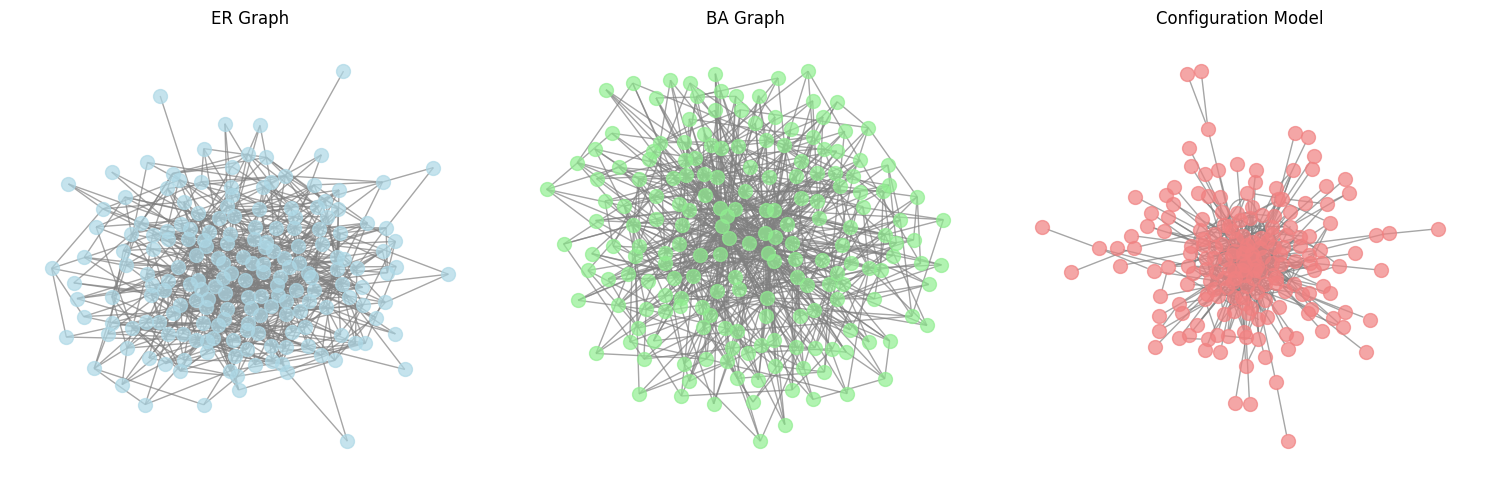

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nx.draw(G_er, ax=axes[0], with_labels=False, node_size=100, node_color='lightblue', edge_color='gray', alpha=0.7)
axes[0].set_title("ER Graph")

nx.draw(G_ba, ax=axes[1], with_labels=False, node_size=100, node_color='lightgreen', edge_color='gray', alpha=0.7)
axes[1].set_title("BA Graph")

nx.draw(G_config, ax=axes[2], with_labels=False, node_size=100, node_color='lightcoral', edge_color='gray', alpha=0.7)
axes[2].set_title("Configuration Model")

plt.tight_layout()
plt.show()

### **1.3 One question — three threads (text + figure)**

Answer **all** of the following in **one** coherent response (Markdown plus one figure as needed). The point is to show you understand **microscopic rule → macroscopic degree shape**, not to copy definitions.

**(1) Mechanism.** In your own words, explain what the **Barabási–Albert** model assumes about **how** the network grows and **how** new edges attach. Then explain **why** that rule tends to produce **hubs** and a **heavy right tail** in degrees compared with a uniform random graph of similar density.

**(2) Plot and read the tail.** Plot the **degree CCDF** on **log–log** axes for **BA**, **ER**, and **GoT** on one figure (legend, readable labels). Use the plot to argue **where** (small, middle, or large degrees) the three networks **agree or disagree**, and what that says about whether “one straight power-law line” would describe all three.

**(3) Counterfactual.** Decide whether this statement is true or false and defend your answer in a few sentences, using the course intuition and/or your figure: *If we kept adding nodes and edges over time but attachments were **not** preferential (e.g. random or uniform among existing nodes), we would still expect the same fat-tailed CCDF as standard BA.*

> The BA model grows by adding nodes one at a time; each newcomer attaches $m$ edges to existing nodes with probability proportional to their degree ($P(i) \alpha k_i$). This linear preferential attachment is a multiplicative “rich‑get‑richer” process: nodes that already have many links gain links faster, so a few nodes accumulate very large degree while most remain small, producing a heavy right tail (asymptotically a power law; BA with linear attachment gives an exponent near 3 for the ideal model).

> On a log–log CCDF the **ER curve drops very steeply** (thin tail), **BA shows an approximately straight** (slowly decaying) line in the upper degrees, and **GoT tracks BA in the large‑k region** but is noisier and bends away at low/mid k. Thus the three agree at small degrees only loosely; they disagree strongly in the tail where ER decays fastest and BA (and GoT) retain much higher mass. The plot implies a single straight power law is not a good description across the entire degree range, it may be a reasonable approximation only above some xmin.

*If we kept adding nodes and edges over time but attachments were **not** preferential (e.g. random or uniform among existing nodes), we would still expect the same fat-tailed CCDF as standard BA.*

> **False**. Growth without preferential attachment (uniform/random attachment) does not by itself produce the same fat tail as BA; it yields a much narrower degree distribution (closer to ER/exponential). **Heavy tails** require a mechanism that **amplifies early** or existing advantage (preferential attachment), persistent heterogeneity in node “fitness,” or similar multiplicative effects, which is why GoT’s similarity to BA in the tail suggests such concentrating mechanisms in the narrative.


### **1.4 Code and figure**


In [6]:
def degree_ccdf(G):
    degrees = np.array([d for _, d in G.degree()])
    values, counts = np.unique(degrees, return_counts=True)
    ccdf = np.cumsum(counts[::-1])[::-1] / counts.sum()
    return values, ccdf

deg_er, ccdf_er = degree_ccdf(G_er)
deg_ba, ccdf_ba = degree_ccdf(G_ba)
deg_got, ccdf_got = degree_ccdf(G_got)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=deg_er, y=ccdf_er,
    mode='markers',
    name='ER',
    marker=dict(size=10, symbol='circle')
))

fig.add_trace(go.Scatter(
    x=deg_ba, y=ccdf_ba,
    mode='markers',
    name='BA',
    marker=dict(size=10, symbol='circle')
))

fig.add_trace(go.Scatter(
    x=deg_got, y=ccdf_got,
    mode='markers',
    name='GoT',
    marker=dict(size=10, symbol='circle')
))

fig.update_xaxes(
    type='log',
    showgrid=False,
    showticklabels=False,
    zeroline=False,
    title='Degree (k)'
)

fig.update_yaxes(
    type='log',
    showgrid=False,
    showticklabels=False,
    zeroline=False,
    title='CCDF P(K ≥ k)'
)

fig.update_layout(
    title='Degree CCDF (log-log scale)',
    hovermode='closest',
    width=800,
    height=600
)

fig.show()

### **1.5 Westeros in the data (short, but required)**

These questions are **not** trivia about the plot: they ask you to connect **quantities you computed** to **how a long serial story is written and read**. Use only Book 1 co-occurrence structure (your graph) plus your comparison models.

1. **Who sits in the tail?** From **`G_got`**, list the **five highest-degree** character names (from the data). In **four to six sentences**, interpret **high degree** here as **“often appears within a few words of many different others”** — what kind of narrative role does that usually imply in an ensemble cast? (You do not need to summarise events; stay at the level of **structural** visibility.)

2. **“Rich get richer” on the page?** BA is a caricature of **preferential attachment**. After looking at your **GoT vs ER** CCDF, argue in **four to six sentences** whether **co-mention popularity** in Book 1 **behaves more like** “attention concentrates on a few hubs” or “everyone is roughly interchangeable at the same density” — and say what part of your figure supports that.

3. **Random partners, same head-counts.** The configuration model keeps **each character’s number of co-mention partners** but shuffles **who** those partners are. In **four to six sentences**, explain what aspects of **story organisation** (stable groups, recurring pairs, geography, family lines — pick what fits your intuition) would be **lost** in that random world even though **degrees** match — and name **one statistic you will compute in Part 4** that might still differ between GoT and CM.


**1. Who sits in the tail?**

In [7]:
# Top 5 highest-degree characters
top5 = sorted(G_got.degree, key=lambda x: x[1], reverse=True)[:5]

for name, deg in top5:
    print(name, deg)

Eddard-Stark 66
Robert-Baratheon 50
Tyrion-Lannister 46
Catelyn-Stark 43
Jon-Snow 37


> In the GoT co-occurrence network, the highest-degree characters are the ones who appear near many different characters throughout the narrative. Structurally, a high-degree node represents a character with broad visibility across multiple parts of the story rather than simply “importance” in a literary sense. These characters often act as bridges between groups, locations, or subplots, which naturally increases their number of co-occurrence partners. In an ensemble cast, high-degree characters usually occupy central narrative positions because the story repeatedly returns to them and connects them with many social circles. This also means they become hubs in the network, helping tie together otherwise separated portions of the graph. Compared with a random graph, the presence of a few very highly connected characters suggests that narrative attention is concentrated unevenly rather than distributed uniformly across all characters.

**2. “Rich get richer” on the page?**

> The GoT CCDF looks much closer to the BA heavy-tailed pattern than to the rapidly decaying ER curve. In the ER graph, the probability of observing very high-degree nodes falls quickly, meaning that most nodes remain near the average degree. By contrast, the GoT network maintains a heavier right tail, showing that a small number of characters accumulate substantially more co-occurrence partners than most others. This suggests that co-mention visibility in the story behaves more like concentrated attention around a few hubs rather than a world where all characters are roughly interchangeable. The evidence for this comes from the large-degree region of the log–log CCDF, where GoT decays much more slowly than ER. Although GoT is not a perfect BA network, its tail indicates stronger inequality in narrative visibility than would emerge from purely random wiring.

**3. Random partners, same head-counts**

> In our intuition, the most important organising features in Game of Thrones are stable groups formed by family lines, political factions, and geography-based clusters that keep certain characters interacting repeatedly within the same narrative spaces. The configuration model destroys this structure by randomly rewiring edges, so although each character keeps the same number of partners, those partners no longer belong to consistent groups or shared story contexts. This means that tightly knit units like Houses, court alliances, or regional clusters are broken apart, and interactions that originally reflected long-term relationships and shared plotlines become arbitrary. Even if a character remains highly connected, those connections no longer carry the narrative meaning of belonging to a coherent group or storyline. As a result, the model preserves local connectivity but loses the underlying story organisation that makes the network meaningful. One statistic that could still differ strongly between GoT and the configuration model is the clustering coefficient, since real narrative groups tend to form tightly interconnected triads that random rewiring disrupts.

## Part 3 — Estimating the degree exponent on Westeros

### Goal

You want a **defensible** summary of how fast the **right tail** of the degree distribution decays: not by eyeballing a straight line, but with the **same discrete power-law tail machinery** you saw in lecture, implemented here with **`powerlaw.Fit`** on **integer degrees**. The package returns **`power_law.alpha`** (tail exponent) and **`power_law.xmin`** (where the fitted tail starts).

### What to hand in

Fit **`powerlaw.Fit(..., discrete=True)`** on GoT degrees and report **`power_law.alpha`** (tail exponent), **`power_law.xmin`**, and how many degrees fall in the fitted tail (if the object exposes it; otherwise state the count with `k >= xmin` yourself).

Produce a figure that helps a reader see **where** the tail fit lives: e.g. log–log CCDF of the data with the fitted power-law CCDF and a clear mark at the estimated lower cutoff.

End with a short paragraph in **plain language** about **low-degree saturation** or a **high-degree cutoff** if you see them (Amaral-style reading): does the co-occurrence network look like a perfect power law from degree 1 to the maximum, or does the shape bend away in places that matter for interpretation?

**Westeros:** In **three to five sentences**, interpret your fitted **tail** (high-degree end) for a reader who has not seen your plot: if “degree” is “how many distinct characters share at least one co-occurrence window with this name,” does a **heavy tail** suggest **many** barely-connected walk-ons and **few** names that anchor a lot of local scenes, or the opposite? Keep the answer tied to **degrees**, not to plot events you cannot see in the data.


In [26]:
def degree_ccdf(G):
    degrees = np.array([d for _, d in G.degree()])
    values, counts = np.unique(degrees, return_counts=True)

    # CCDF: P(K >= k)
    ccdf = np.cumsum(counts[::-1])[::-1] / counts.sum()
    return values, ccdf

deg_got, ccdf_got = degree_ccdf(G_got)
degrees = np.array([d for _, d in G_got.degree()])

fit = pl.Fit(degrees, discrete=True)

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

x_fit = np.logspace(
    np.log10(xmin),
    np.log10(deg_got.max()),
    200
)

ccdf_fit_raw = fit.power_law.ccdf(x_fit)
y_at_xmin = ccdf_got[deg_got >= xmin][0]
ccdf_fit = ccdf_fit_raw * y_at_xmin

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=deg_got,
    y=ccdf_got,
    mode='lines',
    name='GoT empirical CCDF',
    line=dict(width=2)
))


fig.add_trace(go.Scatter(
    x=x_fit,
    y=ccdf_fit,
    mode='lines',
    name=f'Power-law fit (α={alpha:.2f})',
    line=dict(dash='dash')
))


fig.add_trace(go.Scatter(
    x=[xmin, xmin],
    y=[min(ccdf_got), 1],
    mode='lines',
    name=f'xmin={xmin}',
    line=dict(dash='dot')
))


fig.add_vrect(
    x0=min(deg_got),
    x1=xmin,
    fillcolor="darkgray",
    opacity=0.4,
    line_width=0,
)

fig.update_xaxes(
    type='log',
    title='Degree (k)',
    showgrid=False,
    zeroline=False,
    showticklabels=False
)

fig.update_yaxes(
    type='log',
    title='CCDF P(K ≥ k)',
    showgrid=False,
    zeroline=False,
    showticklabels=False
)

fig.update_layout(
    title='GoT Degree Distribution CCDF with Power-law Fit',
    width=850,
    height=600,

    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1,
        xanchor='center',
        x=0.5
    )
)

fig.show()

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 30/30 [00:00<00:00, 286.73it/s]


> **Discussion:** The fitted exponent $\alpha$ describes how quickly the probability of very high-degree nodes decays in the tail of the distribution for degrees $\geq$ $x_{min}$. A **smaller** $\alpha$ indicates a heavier tail and a **higher likelihood of extreme hubs**, while a **larger** $\alpha$ implies faster decay and **fewer highly connected nodes**. Here, $x_{min}$ defines the threshold above which the power-law model is considered valid. Below this value, the degree distribution deviates from pure scaling due to effects such as finite network size and localized clustering of characters that frequently co-occur. Restricting the fit to degrees above $x_{min}$ reflects that the Game of Thrones network does not follow a power law across all degrees. Instead, it shows curvature at low and intermediate values, with approximate linear behavior on a log–log scale only in the upper tail.

**Westeros interpretation (3–5 sentences)**

> The fitted tail shows strong inequality in character co-occurrence. Most characters have few connections, while a small number act as highly connected hubs. These hubs correspond to central figures who link multiple scenes and social groups, whereas most characters remain in localized contexts. This creates a heavy-tailed structure where interactions are concentrated around a small set of narrative anchors. However, since the power-law holds only above xmin, this hub structure mainly describes the upper end of the network rather than its full range.

## Part 2 — Your own tail-exponent estimate vs the `powerlaw` package

### Goal

You should leave this part convinced that **`fit.power_law.alpha`** means something concrete: it is (under the discrete power-law tail model from **Lecture 10**) the exponent that **best explains** the observed degrees **above** the cutoff **`xmin`**. You will **not** use `powerlaw` to *find* that best exponent in one step; instead you **search yourself** over many trial exponents, score each trial with the **log-likelihood** from the lecture (that is the **maximum likelihood** idea), pick the best trial, and **then** call **`powerlaw.Fit(..., discrete=True, xmin=...)`** with the **same** **`xmin`** and the **same** degree data to confirm the package’s **`power_law.alpha`** matches your winner (up to small differences if your search grid is coarse).

Use **`xmin = int(fit_got.power_law.xmin)`** from Part 3 so everyone uses the **same** tail definition (unless Moodle gives one fixed integer).

You also run a **synthetic sanity check** (heavy-tailed integers from **`numpy.random.zipf`**) so you can see **your search** and **`powerlaw`** agree when the data are “friendly.”

### Tasks

1. On **BA** degrees, run an **automatic** `powerlaw.Fit` (`discrete=True`) and record **`power_law.alpha`** and **`power_law.xmin`** — same vocabulary as GoT, different graph.

2. **Your own best exponent (no `powerlaw` for the search):** Using the **discrete power-law** formula on degrees **k >= xmin** from **Lecture 10**, try many candidate tail exponents; for each candidate, compute the **total log-likelihood** of the data in the tail; pick the candidate with the **largest** score. Call that **`exponent_hat_own`** (or any clear name). Then run **`powerlaw.Fit(..., discrete=True, xmin=xmin)`** on the **same** BA degrees and read **`power_law.alpha`**. Report both numbers and the absolute difference. If the gap is not tiny, say honestly that a **finer search grid** (or a proper optimiser) would shrink it — that is expected and fine.

3. **Synthetic check:** draw a large sample from **`numpy.random.zipf`** (parameter on Moodle or **2.5**), keep values **>= xmin**, repeat step 2 (own search vs `powerlaw` with the same **`xmin`**). Zipf is not exactly the same generative model as a pure discrete power law, but **own** and **package** should still be **close** if the pipeline is correct.


**TASK 1**: On **BA** degrees, run an **automatic** `powerlaw.Fit` (`discrete=True`) and record **`power_law.alpha`** and **`power_law.xmin`** — same vocabulary as GoT, different graph.


In [9]:
degrees_ba = np.array([d for n, d in G_ba.degree()])
fit_ba = pl.Fit(degrees_ba, discrete=True)

alpha_ba_pkg = fit_ba.power_law.alpha
xmin_ba_pkg = fit_ba.power_law.xmin

print("=" * 60)
print("TASK 1: BA Graph")
print("=" * 60)
print(f"BA power_law.alpha (package): {alpha_ba_pkg:.4f}")
print(f"BA power_law.xmin (package): {xmin_ba_pkg}")

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 22/22 [00:00<00:00, 249.83it/s]

TASK 1: BA Graph
BA power_law.alpha (package): 2.7056
BA power_law.xmin (package): 4.0



c:\Users\wwwnj\OneDrive - NOVAIMS\Desktop\Network Analysis\.venv\Lib\site-packages\powerlaw\distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


**TASK 2**: Using the **discrete power-law** formula on degrees **k >= xmin** from **Lecture 10**, try many candidate tail exponents; for each candidate, compute the **total log-likelihood** of the data in the tail; pick the candidate with the **largest** score. Call that **`exponent_hat_own`** (or any clear name). Then run **`powerlaw.Fit(..., discrete=True, xmin=xmin)`** on the **same** BA degrees and read **`power_law.alpha`**. Report both numbers and the absolute difference. If the gap is not tiny, say honestly that a **finer search grid** (or a proper optimiser) would shrink it — that is expected and fine.

In [10]:
try:
    if 'fit_got' in globals():
        xmin_shared = int(fit_got.power_law.xmin)
    elif 'fit' in globals():
        xmin_shared = int(fit.power_law.xmin)
    else:
        # compute GoT fit if neither name exists
        degrees = np.array([d for n, d in G_got.degree()])
        fit_got = pl.Fit(degrees, discrete=True)
        xmin_shared = int(fit_got.power_law.xmin)
except NameError:
    xmin_shared = int(fit.power_law.xmin)
ba_tail = degrees_ba[degrees_ba >= xmin_shared]

print(f"\nUsing shared xmin = {xmin_shared} from GoT fit")
print(f"Number of BA degrees >= xmin: {len(ba_tail)}")


Using shared xmin = 5 from GoT fit
Number of BA degrees >= xmin: 123


In [11]:
def discrete_power_law_loglik(degrees_tail, alpha, xmin):
    """
    Log-likelihood of degrees_tail under discrete power law with exponent alpha,
    cutoff xmin. Uses the Riemann zeta normalization.
    """
    if alpha <= 1:
        return -np.inf
    zeta_val = scipy.special.zeta(alpha, xmin)
    if zeta_val <= 0:
        return -np.inf
    
    loglik = -alpha * np.sum(np.log(degrees_tail)) - len(degrees_tail) * np.log(zeta_val) 

    return loglik

# grid for alpha
alpha_candidates = np.linspace(1.1, 5.0, 200)
loglik_scores = []

for alpha_cand in alpha_candidates:
    ll = discrete_power_law_loglik(ba_tail, alpha_cand, xmin_shared)
    loglik_scores.append(ll)

loglik_scores = np.array(loglik_scores)
best_idx = np.argmax(loglik_scores)
exponent_hat_own_ba = alpha_candidates[best_idx]
best_loglik_ba = loglik_scores[best_idx]

print(f"\nManual MLE search on BA tail (xmin={xmin_shared}):")
print(f"  exponent_hat_own (BA): {exponent_hat_own_ba:.4f}")
print(f"  power_law.alpha (BA, same xmin): {alpha_ba_pkg:.4f}")
print(f"  Absolute difference: {abs(exponent_hat_own_ba - alpha_ba_pkg):.4f}")


Manual MLE search on BA tail (xmin=5):
  exponent_hat_own (BA): 2.7070
  power_law.alpha (BA, same xmin): 2.7056
  Absolute difference: 0.0014


**TASK 3**: **Synthetic check:** draw a large sample from **`numpy.random.zipf`** (parameter on Moodle or **2.5**), keep values **>= xmin**, repeat step 2 (own search vs `powerlaw` with the same **`xmin`**). Zipf is not exactly the same generative model as a pure discrete power law, but **own** and **package** should still be **close** if the pipeline is correct.

In [12]:
print("\n" + "=" * 60)
print("TASK 3: Synthetic Zipf Check")
print("=" * 60)

# Draw large Zipf sample (parameter a=2.5)
zipf_a = 2.5
zipf_sample = RNG.zipf(zipf_a, size=10000)
zipf_tail = zipf_sample[zipf_sample >= xmin_shared]

print(f"Zipf sample size: {len(zipf_sample)}, tail size (>= xmin): {len(zipf_tail)}")

# Own search on Zipf
loglik_scores_zipf = []
for alpha_cand in alpha_candidates:
    ll = discrete_power_law_loglik(zipf_tail, alpha_cand, xmin_shared)
    loglik_scores_zipf.append(ll)

loglik_scores_zipf = np.array(loglik_scores_zipf)
best_idx_zipf = np.argmax(loglik_scores_zipf)
exponent_hat_own_zipf = alpha_candidates[best_idx_zipf]

# Package fit on Zipf
fit_zipf = pl.Fit(zipf_sample, discrete=True, xmin=xmin_shared)
alpha_zipf_pkg = fit_zipf.power_law.alpha

print(f"\nManual MLE search on Zipf tail (xmin={xmin_shared}):")
print(f"  exponent_hat_own (Zipf): {exponent_hat_own_zipf:.4f}")
print(f"  power_law.alpha (Zipf, same xmin): {alpha_zipf_pkg:.4f}")
print(f"  Absolute difference: {abs(exponent_hat_own_zipf - alpha_zipf_pkg):.4f}")
print(f"\nNote: Zipf parameter a={zipf_a} should roughly match exponent ≈ {zipf_a:.1f}")


TASK 3: Synthetic Zipf Check
Zipf sample size: 10000, tail size (>= xmin): 559

Manual MLE search on Zipf tail (xmin=5):
  exponent_hat_own (Zipf): 2.3739
  power_law.alpha (Zipf, same xmin): 2.3761
  Absolute difference: 0.0022

Note: Zipf parameter a=2.5 should roughly match exponent ≈ 2.5


## Part 4 — Same numbers, different stories

### Goal

You now have **four** objects: GoT, a **configuration** rewiring of GoT’s **degrees**, your **BA** graph, and your **ER** graph. The assignment ends by asking you to **synthesise**: which objects match on **size**, which on **degree histogram**, which on **tail exponent summaries**, and which still differ on **triangle-heavy structure** (clustering). That is the scientific payoff: **first-order** (degree) similarity does not imply **second-order** (clustering / triangles) similarity.

### What to produce

A **table** (Markdown or `pandas`) with one row each for **GoT**, **configuration model**, **BA**, and **ER**. Columns should include at least: **N**, **L**, **mean degree**, **one global clustering summary you define** (name it), **tail exponent** **`power_law.alpha`**, and **tail start** **`power_law.xmin`**, from **`powerlaw.Fit(..., discrete=True)`** on the **degree sequence** you analyse for that row (for the configuration multigraph, use the **degree** reported by the multigraph so it matches GoT’s multiset).

**Note:** NetworkX’s usual **global transitivity** is defined for **simple** graphs. For the configuration **MultiGraph**, either justify a clustering measure you can compute, or explain why you report **“not directly comparable”** and still compare GoT vs ER vs BA honestly.

### Closing paragraph

Write **150–250 words** tying the table back to the big picture: What does the configuration model prove about **degrees** alone? Why might **`power_law.alpha`** for GoT and CM line up even when clustering does not? Why is ER the wrong place to look for the same tail story as GoT?

**Westeros (include inside the same paragraph or just after it, about half a page total):** Imagine the configuration rewiring as a **counterfactual book** where every character still meets the **same number** of others, but **which** pairings are co-mentions are scrambled. Would you expect **families, locations, and chapters** to “clump” in the text the same way? Say explicitly how your **clustering** column supports or contradicts that intuition — again, **structure from the graph**, not a recap of the novel.~


In [13]:
rows = []
models = [
    ("GoT", G_got),
    ("Configuration (multigraph)", G_config),
    ("BA", G_ba),
    ("ER", G_er),
]

for name, G in models:
    N_i = G.number_of_nodes()
    L_i = G.number_of_edges()
    mean_deg_i = np.mean([d for _, d in G.degree()])

    # Define clustering summary (global transitivity). For multigraph we simplify first and note incomparability.
    if isinstance(G, (nx.MultiGraph, nx.MultiDiGraph)):
        G_simple = nx.Graph(G)  # collapse parallel edges / self-loops for clustering measure
        clustering_val = nx.transitivity(G_simple)
        clustering_note = "transitivity on simplified simple graph (not directly comparable to simple-graph values)"
    else:
        clustering_val = nx.transitivity(G)
        clustering_note = "global transitivity (comparable)"

    # Degree sequence and powerlaw fit
    degs = np.array([d for _, d in G.degree()])
    # reuse existing fits if available to save time
    if name == "GoT" and 'fit_got' in globals():
        fit_obj = fit_got
    elif name == "BA" and 'fit_ba' in globals():
        fit_obj = fit_ba
    else:
        fit_obj = pl.Fit(degs, discrete=True)

    alpha_i = fit_obj.power_law.alpha
    xmin_i = int(fit_obj.power_law.xmin)

    rows.append({
        "model": name,
        "N": N_i,
        "L": L_i,
        "mean_degree": mean_deg_i,
        "clustering (global transitivity)": clustering_val,
        "clustering_note": clustering_note,
        "power_law.alpha": alpha_i,
        "power_law.xmin": xmin_i
    })

summary = pd.DataFrame(rows).set_index("model")
display(summary)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 30/30 [00:00<00:00, 372.35it/s]


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 30/30 [00:00<00:00, 458.96it/s]

Calculating best minimal value for power law fit

Fitting xmin: 100%|██████████| 13/13 [00:00<00:00, 248.92it/s]
c:\Users\wwwnj\OneDrive - NOVAIMS\Desktop\Network Analysis\.venv\Lib\site-packages\powerlaw\distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


,N,L,mean_degree,clustering (global transitivity),clustering_note,power_law.alpha,power_law.xmin
model,,,,,,,
GoT,187,684,7.315508,0.330234,global transitivity (comparable),2.204578,5
Configuration (multigraph),187,684,7.315508,0.161526,transitivity on simplified simple graph (not d...,2.204578,5
BA,187,732,7.828877,0.092155,global transitivity (comparable),2.705640,4
ER,187,684,7.315508,0.047976,global transitivity (comparable),2.833154,5


> The configuration model reproduces the key first order properties of the GoT network. It matches the number of nodes, number of links, and the full degree multiset. By contrast, BA and ER fail to match either link counts or the observed degree distribution. This demonstrates the main limitation of degree-based modeling. Preserving how many connections each node has does not determine how those connections are arranged. Higher order structure remains unconstrained.
>
>The similar power law alpha values for GoT and the configuration model follow from this. Both share the same degree multiset, and tail exponent estimates depend mainly on that distribution. A random rewiring that preserves degrees therefore tends to preserve the fitted tail behavior.
>
> Clustering reveals the structural gap. The GoT network has much higher global transitivity than the configuration model or ER. This indicates a strong presence of triangles and tightly knit groups. The configuration model disrupts these patterns even while keeping node level connectivity fixed. ER is not appropriate for modeling the GoT tail. Its degree distribution is too thin and homogeneous to generate large hubs, so it cannot reproduce the observed heavy tail.
>
> Interpreted narratively, the configuration model is a counterfactual version of the story. Characters retain the same number of interactions, but stable groups such as families or locations disappear. The drop in clustering captures this loss and shows that narrative cohesion depends on more than degree counts.
